<a href="https://colab.research.google.com/github/daniel-usp/USP/blob/main/IA_Robo_Trader_FIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Usando IA para construir uma estratégia de investimentos no Python

# 🚀 **Desvendando Estratégias de Investimento com IA** 🧠💼

**Prepare-se para uma aventura incrível no mundo dos investimentos inteligentes!** 🌟 Hoje, vamos explorar como a **Inteligência Artificial (IA)** pode transformar suas estratégias de investimento, tornando-as mais eficazes e assertivas! 📈

## 🎯 **O que é 'Aprender com os Dados'?**

Quando falamos de **modelos de aprendizado de máquina**, estamos falando de **aprender com os dados**! 🤖 Mas imagine se pudéssemos aplicar essa mesma ideia às **estratégias de investimento**? 🌐💸 Vamos ver como isso funciona na prática!

### 🛠️ **Mãos à Obra: Exercício com Python**

Vamos realizar um exercício em Python usando **Redes Neurais Profundas** (DNNs) 🧠 para prever os movimentos do mercado financeiro 📉📈. Nosso ponto de partida? Os **log-retornos históricos** como dados de entrada!

## 🧠 **Entendendo as DNNs: O Poder das Camadas!**

As **DNNs** são inspiradas no cérebro humano 🧠 e são compostas por diversas camadas:

- **Camada de Entrada**: Onde os dados brutos entram! 🚪
- **Camadas Ocultas**: Onde a mágica acontece! 🪄
- **Camada de Saída**: Onde obtemos as previsões! 📊

Essa arquitetura permite que as redes neurais aprendam relações complexas e ofereçam um desempenho **superior** em diversos problemas, incluindo a previsão de movimentos do mercado. 💪

### 🔍 **Transformando Dados em Padrões de Mercado**

Com as **DNNs**, podemos pegar os valores defasados da série temporal 📅 e transformá-los em novas *features* 🌟, buscando identificar **padrões e tendências** que antes eram invisíveis aos olhos humanos! 👀

## 🔄 **Backtesting de Estratégias de Algo-Trading**

Agora, vamos falar de algo **ainda mais emocionante**: **Backtesting de estratégias de Algo-Trading**! 🚀

**O que é Algo-Trading?** 🤔 Nada mais é do que a negociação automatizada de instrumentos financeiros, baseada em **algoritmos inteligentes** 🧠, que tomam decisões de compra, venda ou manutenção de posição de forma **automática** e sem intervenção humana. 🖥️📊

### 🧪 **Experimente e Aprenda!**

Chegou a hora de colocar a mão na massa! 🛠️ Abra seu Colab e vamos criar **modelos que aprendem com o passado para prever o futuro**! 🔮 Quem sabe, você não descobre a próxima grande estratégia de investimento? 💡💰

---

**Vamos nessa?** 🚀💥 FIA LabData


# 1. Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import yfinance as yf
from plotnine import *

# 2. Dados

Para fins de aprendizado, vamos buscar dados da empresa VALE3 no período de jan/2010 até dez/2022, em intervalo diário. Filtramos o preço de fechamento, e calculamos os log-retornos da série. Em seguida, criamos as defasagens do log-retorno.

In [ ]:
# Data inicio/fim
inicio = '2015-08-01'
fim = '2024-08-21'

# Ticker
symbol = 'ABEV3.SA'

# Importa os preços da ABEV3
data = yf.download(tickers = symbol,
                   start = inicio,
                   end = fim)[['Close']]

[*********************100%***********************]  1 of 1 completed


In [ ]:
# Log retornos
data = data.assign(returns = np.log(data['Close'] / data['Close'].shift(1)).values)

# Retira dados faltantes
data.dropna(inplace=True)

# Direção dos retornos (positivo/negativo)
data['direction'] = np.sign(data['returns']).astype(int)

A ideia básica por trás do uso de retornos logarítmicos defasados como *features* é que eles podem ser informativos na previsão de retornos futuros. Por exemplo, alguém pode hipotetizar que após dois movimentos descendentes, um movimento ascendente é mais provável ("reversão à média"), ou, ao contrário, que outro movimento descendente é mais provável ("momentum" ou "tendência").

In [ ]:
lags = 5 # lags utilizados para prever o direcionamento

# função para criar os lags
def create_lags(data):
  global cols
  cols = []
  for lag in range(1, lags + 1):
    col = 'lag_{}'.format(lag)
    data[col] = data['returns'].shift(lag)
    cols.append(col)

# Cria os lags
create_lags(data)
data.dropna(inplace = True)

data.head()

,Close,returns,direction,lag_1,lag_2,lag_3,lag_4,lag_5
Date,,,,,,,,
2015-08-11,19.730000,0.009677,1,0.008222,-0.025473,-0.003515,0.011089,0.006611
2015-08-12,18.900000,-0.042978,-1,0.009677,0.008222,-0.025473,-0.003515,0.011089
2015-08-13,18.660000,-0.012780,-1,-0.042978,0.009677,0.008222,-0.025473,-0.003515
2015-08-14,18.559999,-0.005373,-1,-0.012780,-0.042978,0.009677,0.008222,-0.025473
2015-08-17,18.590000,0.001615,1,-0.005373,-0.012780,-0.042978,0.009677,0.008222


Podemos também transformar as defasagens de valor contínuo em *features* binárias e avaliar a probabilidade de um movimento ascendente e um movimento descendente, respectivamente, a partir das observações históricas desses movimentos.

In [ ]:
# Função para criar os sinais (valores das variáveis dependentes)
def create_bins(data, bins=[0]):
  global cols_bin
  cols_bin = []
  for col in cols:
    col_bin = col + '_bin'
    data[col_bin] = np.digitize(data[col], bins=bins)
    cols_bin.append(col_bin)

# Cria as variáveis binárias
create_bins(data)

data

,Close,returns,direction,lag_1,lag_2,lag_3,lag_4,lag_5,lag_1_bin,lag_2_bin,lag_3_bin,lag_4_bin,lag_5_bin
Date,,,,,,,,,,,,,
2015-08-11,19.730000,0.009677,1,0.008222,-0.025473,-0.003515,0.011089,0.006611,1,0,0,1,1
2015-08-12,18.900000,-0.042978,-1,0.009677,0.008222,-0.025473,-0.003515,0.011089,1,1,0,0,1
2015-08-13,18.660000,-0.012780,-1,-0.042978,0.009677,0.008222,-0.025473,-0.003515,0,1,1,0,0
2015-08-14,18.559999,-0.005373,-1,-0.012780,-0.042978,0.009677,0.008222,-0.025473,0,0,1,1,0
2015-08-17,18.590000,0.001615,1,-0.005373,-0.012780,-0.042978,0.009677,0.008222,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-14,12.560000,-0.000796,-1,0.014423,-0.004831,0.007255,-0.012063,0.040789,1,0,1,0,1
2024-08-15,13.030000,0.036737,1,-0.000796,0.014423,-0.004831,0.007255,-0.012063,0,1,0,1,0
2024-08-16,13.010000,-0.001536,-1,0.036737,-0.000796,0.014423,-0.004831,0.007255,1,0,1,0,1


# 3. Treinamento do Modelo

O algoritmo é treinado e testado em dados de *features* binárias ou contínuas. A ideia é que os padrões de valores das *features* permitam uma previsão dos movimentos futuros do mercado com uma taxa de acerto melhor do que 50%. Implicitamente, presume-se que o poder preditivo dos padrões persista ao longo do tempo. Nesse sentido, não deveria fazer (muita) diferença em qual parte dos dados um algoritmo é treinado e em qual parte dos dados ele é testado - implicando que se pode quebrar a sequência temporal dos dados para treinamento e teste (sempre haverá a possibilidade de implementação de separação sequencial e o uso de cross-validation).

Uma maneira típica de fazer isso é dividir aleatoriamente os dados em treino e teste para testar o desempenho dos algoritmos fora da amostra, tentando emular a realidade, onde um algoritmo durante a negociação se depara continuamente com novos dados.

Aplicamos a separação dos conjuntos de dados aleatoriamente e aplicamos o modelo DNN. Isso evita que tenhamos *overfitting* na nossa estratégia.

In [ ]:
# Dividindo os dados em conjuntos de treinamento e teste com uma proporção de 50% para cada
train, test = train_test_split(data, test_size=0.5, random_state=100)

# Copiando e classificando os conjuntos de treinamento e teste com base nos índices
train = train.copy().sort_index()
test = test.copy().sort_index()

# Definindo o modelo de classificação MLP (DNN) com os parâmetros especificados
model = MLPClassifier(solver='lbfgs', alpha=1e-5, max_iter=500, hidden_layer_sizes=3 * [500], random_state=1)

# Treinando o modelo com os dados de treinamento, utilizando apenas as características binárias (cols_bin) e a direção como rótulo
model.fit(train[cols_bin], train['direction'])

MLPClassifier(alpha=1e-05, hidden_layer_sizes=[500, 500, 500], max_iter=500,
              random_state=1, solver='lbfgs')

Com a previsão direcional em mãos, podemos aplicar o backtesting vetorizado para avaliar o desempenho das estratégias de negociação desenvolvidas. Nesta etapa, nossa análise se baseia em uma série de suposições simplificadoras, incluindo "custos de transação zero" e a utilização do mesmo conjunto de dados tanto para o treinamento quanto para o teste dos modelos.

In [ ]:
# Fazendo previsões usando o modelo treinado nos dados de teste e armazenando os resultados em uma nova coluna 'pos_dnn_sk'
test['pos_dnn_sk'] = model.predict(test[cols_bin])

# Calculando os retornos da estratégia com base nas previsões do modelo e nos retornos históricos
test['strat_dnn_sk'] = test['pos_dnn_sk'] * test['returns']

# Somando os retornos históricos e os retornos da estratégia e aplicando a função exponencial para obter o total acumulado
test[['returns', 'strat_dnn_sk']].sum().apply(np.exp)

,0
returns,1.384941
strat_dnn_sk,2.015393


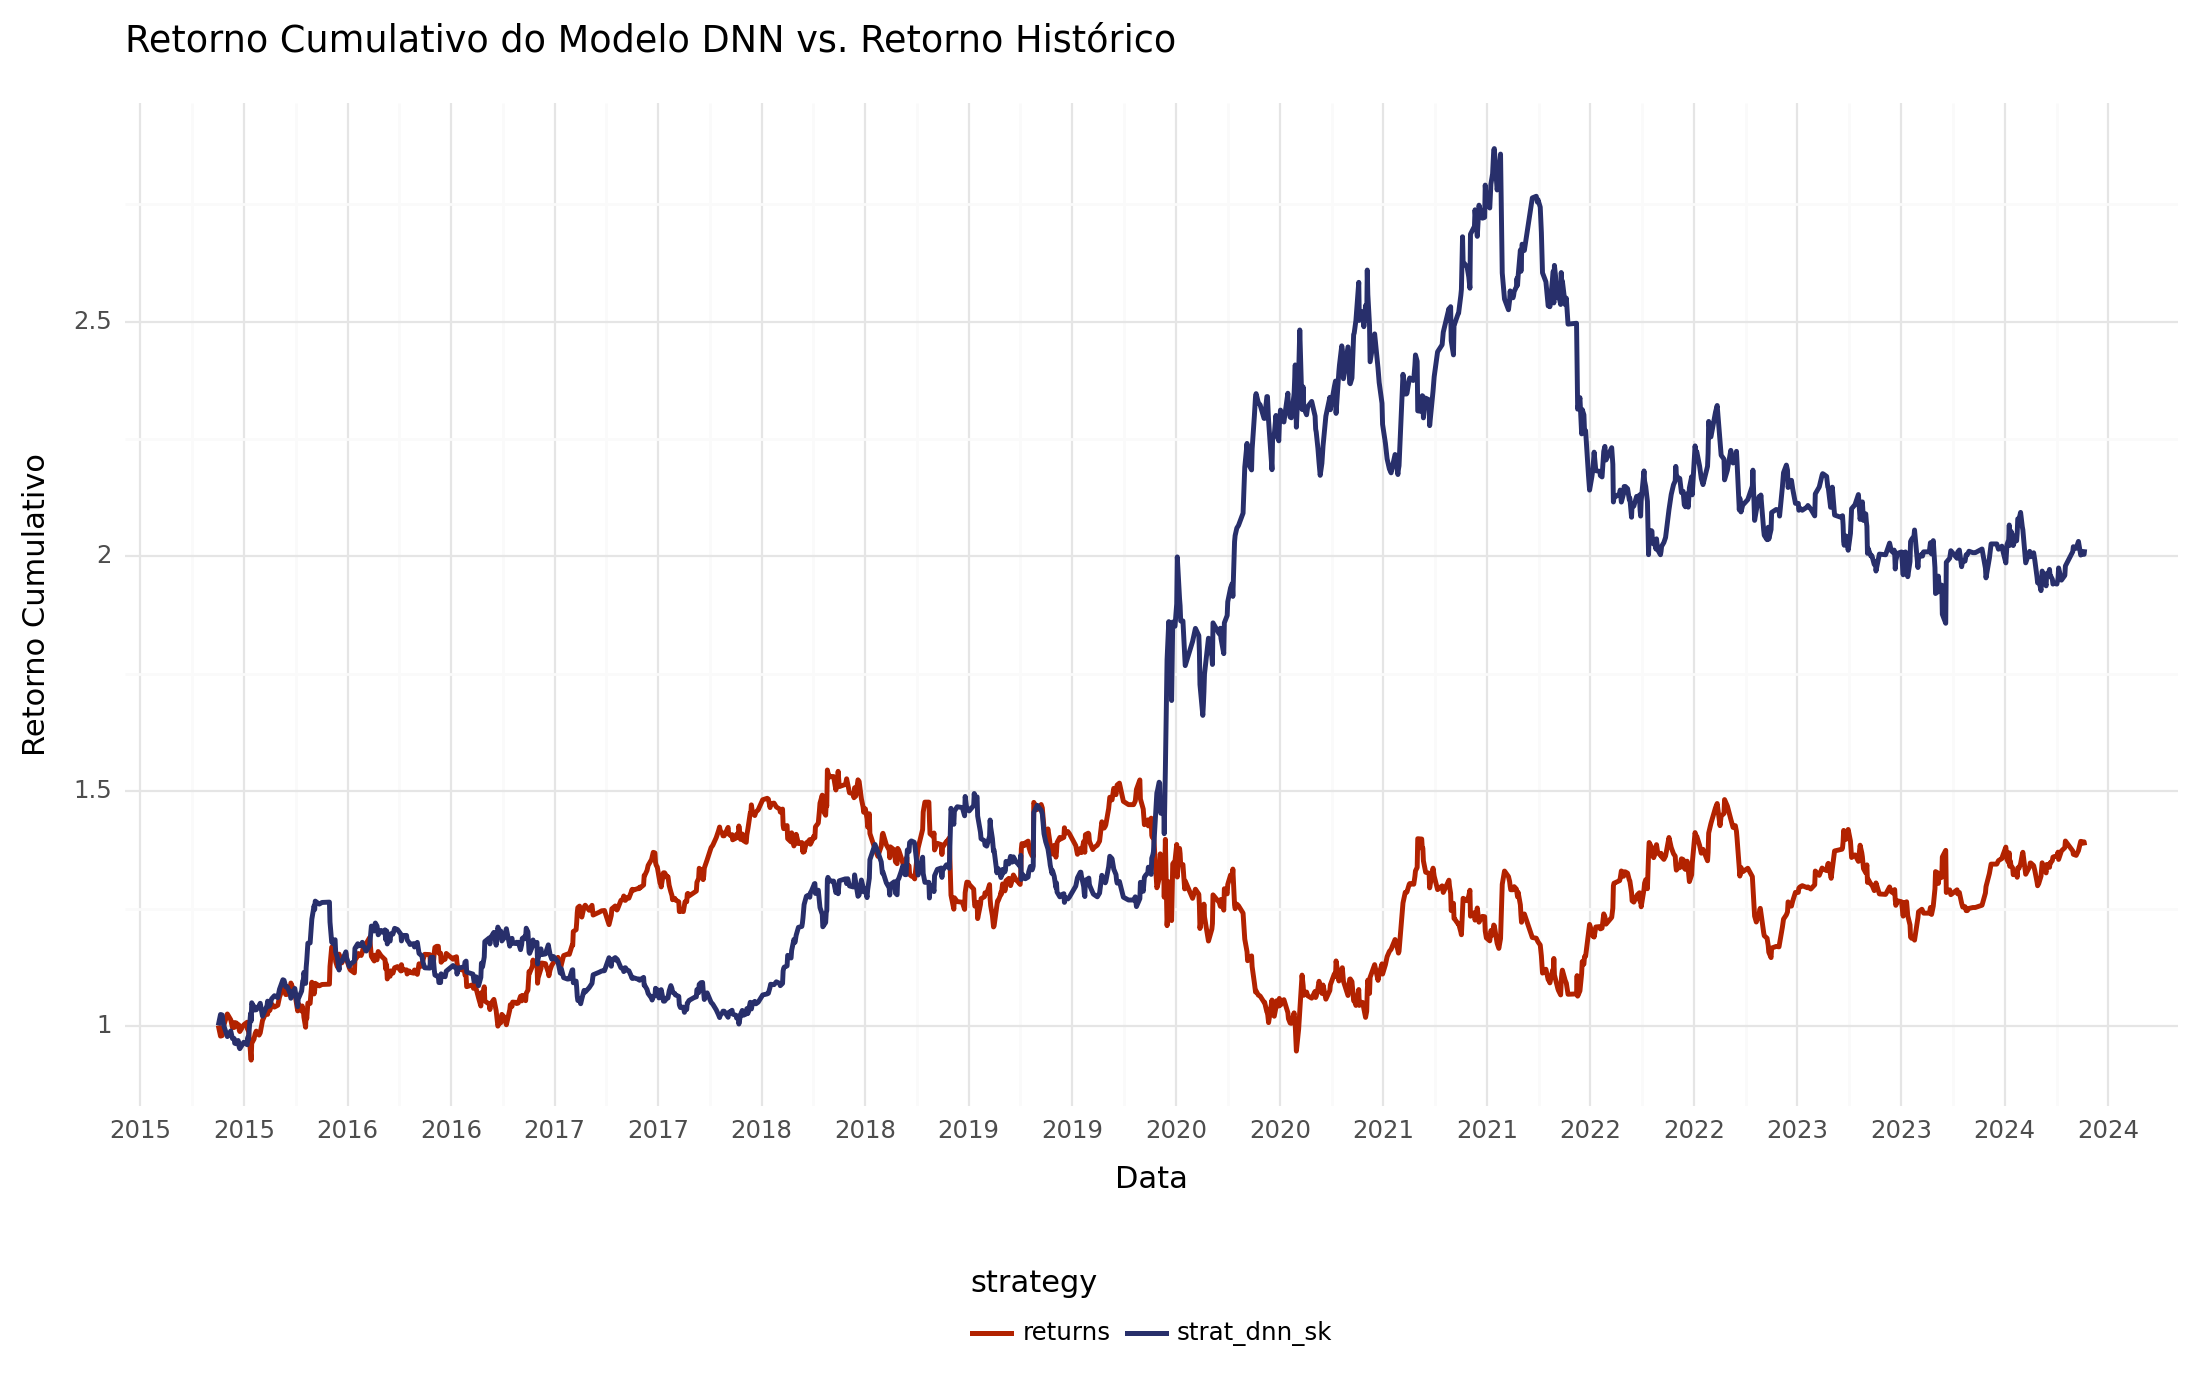

<Figure Size: (1100 x 700)>

In [ ]:
# Calculando os retornos acumulados
cumulative_returns = test[['returns', 'strat_dnn_sk']].cumsum().apply(np.exp)
cumulative_returns.reset_index(inplace=True)

# Transforma em formato long
cumulative_returns_long = cumulative_returns.melt(id_vars = 'Date', var_name='strategy', value_name='cumulative_return')

# Criando o gráfico
(
    ggplot(cumulative_returns_long) +
    aes(x='Date', y='cumulative_return', color='strategy') +
    geom_line(size=1) +
    theme_minimal() +
    scale_color_manual(values = ['#b22200', '#282f6b']) +
    scale_x_datetime(date_breaks = '6 months', date_labels = "%Y") +
    labs(x='Data', y='Retorno Cumulativo', title='Retorno Cumulativo do Modelo DNN vs. Retorno Histórico') +
    theme(legend_position = 'bottom',
          figure_size = (11, 7))
)

(Obs. isso não é recomendação de investimento).